# Google Colab Setup

## Set up a personal access token for colab

### Part 1: github token
1. On your github go to: https://github.com/settings/personal-access-tokens/new
2. Set `Token name *` to: `the-space-cats-colab`
3. Set `Experiation` to `No expiration`
4. Under `Repository access`:
  *   Select option `Only select repositories`
  *   Search and select repo `the-space-cats-project`
5. Under `Permissions`:
    *  Click `Add permissions`
    *  Select option `Contents`
    *  Change `Access: Read-only` to `Access: Read and write`
6. Double check everytjing matches the picture below
7. Save the generated token somewhere safe


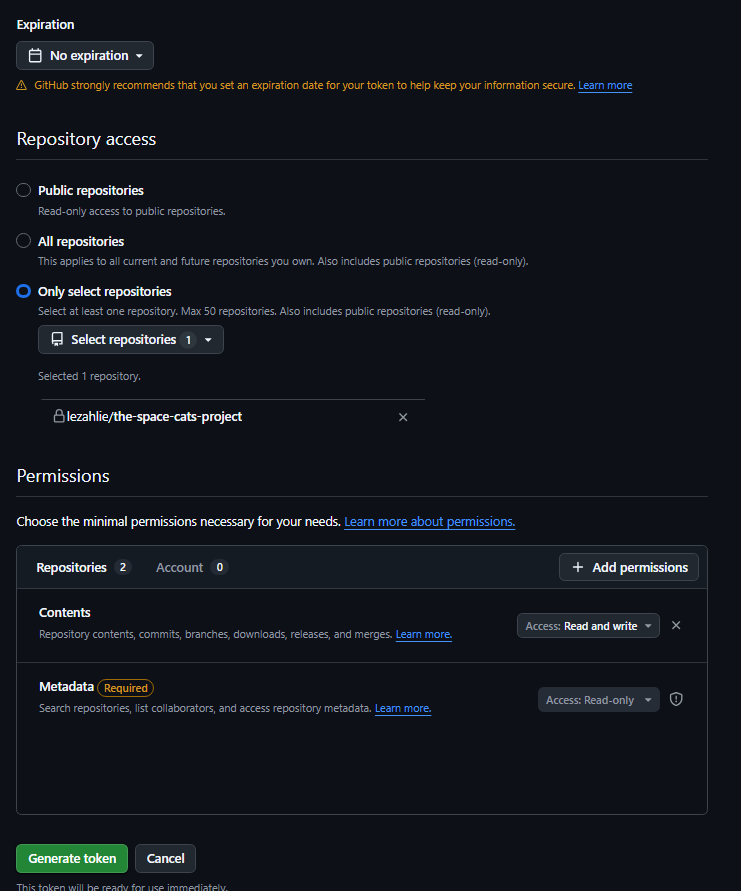

### Part 2: google colab secret

1. In Google Colab select the `Secrets` (key icon) tab
2. Add new secret with name `SPACECATS_GITHUB_TOKEN`
3. Paste the generated token saved from Part 2 - Step 7 in the value field
4. Make sure Notebook access is enabled
5. Confirm with the picture below

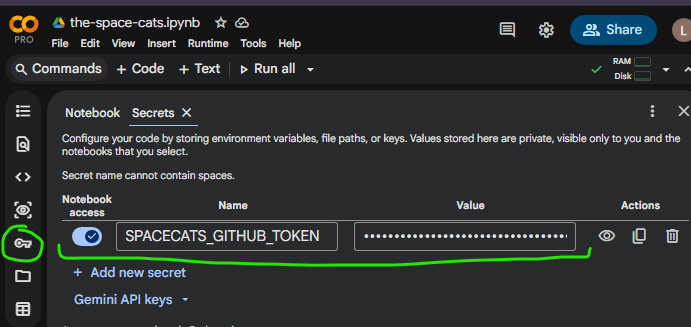

## Part 3: Setup the runtime environment

### Follow the pictures to connect to a GPU

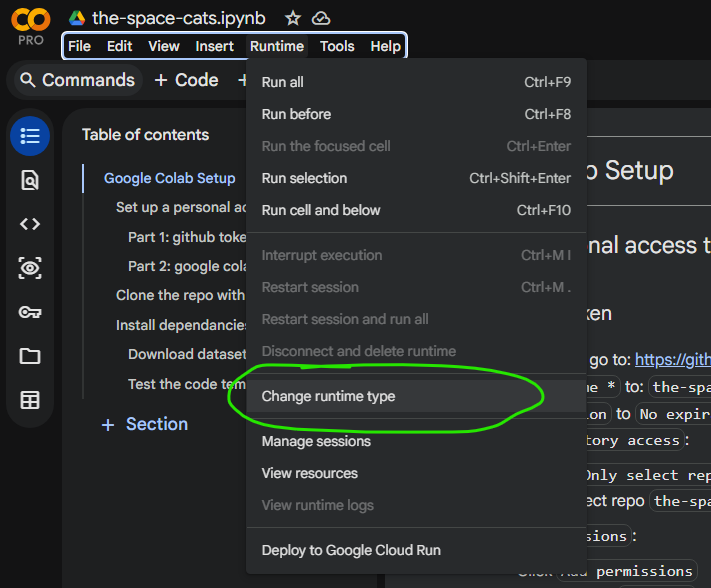

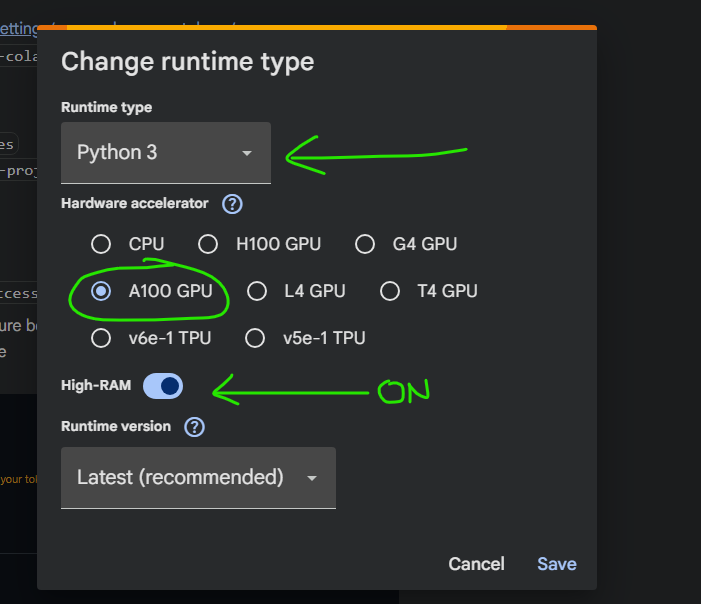

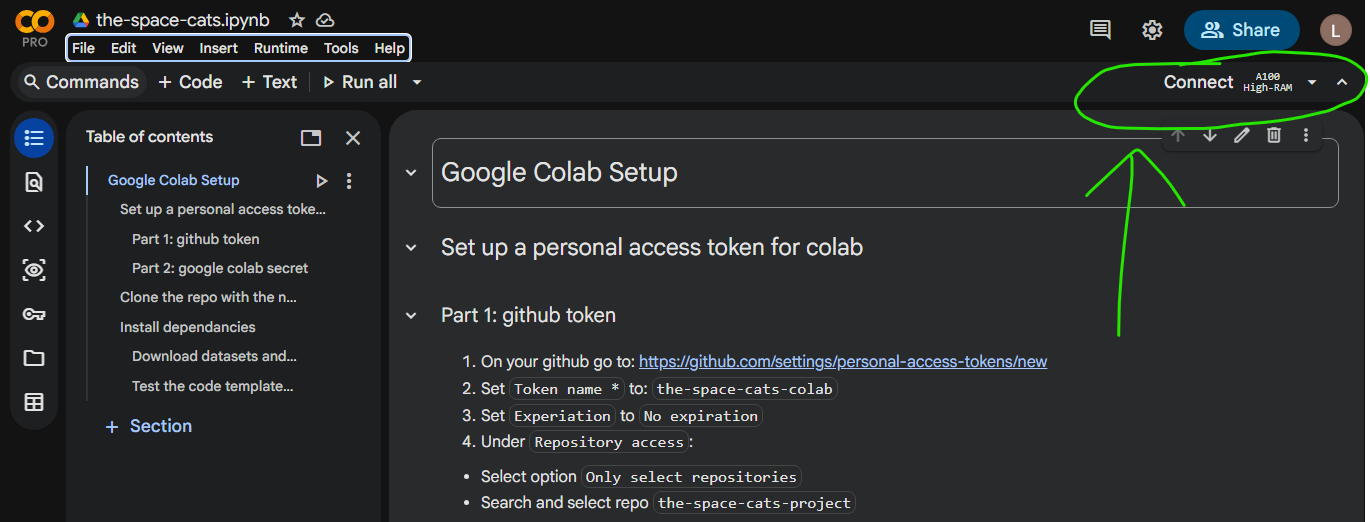

## Part 4: Clone the repo with the new token

### 0. Imports

In [ ]:
from google.colab import userdata, drive
import urllib.parse
import subprocess
import os
import sys

### 1. Enter your first name below

In [ ]:
first_name=""

### 2. Clone the repo OR pull updates if already cloned

In [ ]:
drive.mount("/content/drive")

token = urllib.parse.quote(userdata.get("SPACECATS_GITHUB_TOKEN"), safe="")
repo_url = f"https://{token}@github.com/lezahlie/the-space-cats-project.git"
repo_dir = "/content/drive/MyDrive/the-space-cats-project"
branch = first_name  # or set this to your branch name as a string

def run(cmd, cwd=None):
    print("$", " ".join(cmd))
    subprocess.run(cmd, cwd=cwd, check=True)

# clone only if needed
if not os.path.isdir(os.path.join(repo_dir, ".git")):
    run(["git", "clone", repo_url, repo_dir])

# verify repo
run(["git", "status"], cwd=repo_dir)

# make sure remote refs are current
run(["git", "fetch", "origin"], cwd=repo_dir)

# checkout main and update it
run(["git", "checkout", "main"], cwd=repo_dir)
run(["git", "pull", "origin", "main"], cwd=repo_dir)

# checkout your branch
branch_exists_local = subprocess.run(
    ["git", "rev-parse", "--verify", branch],
    cwd=repo_dir,
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL,
).returncode == 0

if branch_exists_local:
    run(["git", "checkout", branch], cwd=repo_dir)
else:
    branch_exists_remote = subprocess.run(
        ["git", "ls-remote", "--exit-code", "--heads", "origin", branch],
        cwd=repo_dir,
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL,
    ).returncode == 0

    if branch_exists_remote:
        run(["git", "checkout", "-b", branch, f"origin/{branch}"], cwd=repo_dir)
    else:
        run(["git", "checkout", "-b", branch], cwd=repo_dir)

# bring your branch up to date with main
run(["git", "pull", "origin", "main"], cwd=repo_dir)

# push branch and set upstream
run(["git", "push", "-u", "origin", branch], cwd=repo_dir)

## Part 5: Setup the environment
> Note: If a package is already installed, it will auto skip 

In [ ]:
drive.mount("/content/drive")

VENV_DIR = "/content/drive/MyDrive/venvs/spacecats-cu118"
VENV_PYTHON = f"{VENV_DIR}/bin/python"
VENV_PIP = f"{VENV_DIR}/bin/pip"

def run(cmd):
    print("$", " ".join(cmd))
    subprocess.run(cmd, check=True)

# create the venv once
if not os.path.isdir(VENV_DIR):
    run([sys.executable, "-m", "venv", VENV_DIR])

# upgrade packaging tools inside the venv
run([VENV_PIP, "install", "--upgrade", "pip", "setuptools", "wheel"])

# install your project deps into the persistent venv
run([
    VENV_PIP, "install",
    "--extra-index-url", "https://download.pytorch.org/whl/cu118",
    "torch==2.4.1",
    "torchaudio==2.4.1",
    "torchvision==0.19.1",
    "numpy",
    "scipy",
    "scikit-learn",
    "scikit-image",
    "torchmetrics",
    "h5py",
    "jsonschema",
    "pandas",
    "pyyaml",
    "matplotlib",
    "seaborn",
])

#### Set project root to python path (required during initialization)

In [ ]:
old_pythonpath = os.environ.get("PYTHONPATH", "")
paths = old_pythonpath.split(":") if old_pythonpath else []

if repo_dir not in paths:
    os.environ["PYTHONPATH"] = f"{repo_dir}:{old_pythonpath}" if old_pythonpath else repo_dir

if repo_dir not in sys.path:
    sys.path.insert(0, repo_dir)

print("PYTHONPATH =", os.environ.get("PYTHONPATH", ""))
print("sys.path[0] =", sys.path[0])

## Part 6: Test the preprocessing and training pipelines

> 1. Download `galaxiesml_tiny.tar.gz` from: https://gtvault-my.sharepoint.com/:u:/r/personal/lhorace3_gatech_edu/Documents/DLGroupProject_Datasets/galaxiesml_tiny.tar.gz?csf=1&web=1&e=MaHjh7
> 2. Upload the `galaxiesml_tiny.tar.gz` to your google drive `Mydrive` directory
> 3. Run the below cell to extract it to the `data` folder

In [ ]:
!mkdir -p /content/drive/MyDrive/the-space-cats-project/data
!tar -xzf /content/drive/MyDrive/galaxiesml_tiny.tar.gz -C /content/drive/MyDrive/the-space-cats-project/data/

### Test the model works with cuda

In [ ]:
!python src/models/CNNEncoder.py

### Test preprocessing with the tiny dataset

In [ ]:
!python src/preprocess_data.py \
--input-folder data/galaxiesml_tiny \
--output-folder data/preprocessed \
--num-cores 2 \
--mask-ratio 0.5 \
--debug

### Test the tuning works with a tiny grid

In [ ]:
!python src/tune_model.py \
    --input-folder "data/preprocessed/galaxiesml_tiny" \
    --output-folder experiments/tune_debug_grid \
    --num-cores 2 \
    --gpu-memory-fraction 0.9 \
    --debug

### Test the model works with the tiny dataset


In [ ]:
!python src/train_model.py \
--config-file configs/train_config.json \
--input-folder data/preprocessed/galaxiesml_tiny \
--output-folder experiments/train_galaxiesml_tiny \
--gpu-memory-fraction 0.5 \
--num-cores 2 \
--debug

> Important Notes: 
> 1. The config will run 5 epochs with hyper-params that over-fit the model.
> 2. On each epoch you should observe the following:
>     - Both Smooth-L1 and SSIM loss values decrease
>     - Validation sample plots show improved reconstruction

## Part 7: Run your mask ablation experiment

### A. Download the medium reduced dataset

> 1. Download `galaxiesml_medium.tar.gz` from: https://gtvault-my.sharepoint.com/:u:/g/personal/lhorace3_gatech_edu/IQArE7VrCfj2Sqpwv9jNly0JARb2qsCnRMXKgiz8BAt0x-I?e=5ydyFl
> 2. Upload the `galaxiesml_medium.tar.gz` to your google drives `Mydrive` directory
> 3. Run the below cell to extract it to the `data` folder

In [ ]:
!mkdir -p /content/drive/MyDrive/the-space-cats-project/data
!tar -xzf /content/drive/MyDrive/galaxiesml_medium.tar.gz -C /content/drive/MyDrive/the-space-cats-project/data/

### B. Preprocess your mask ratio ablation

#### 1. Make sure your first name and number of cores between [2, 5] are set

In [ ]:
first_name = ""
num_cores = 5

In [ ]:
########################################
# Do not edit this cell
########################################

first_name = first_name.title()

mask_ratios = {
    "Leslie": 0.0,
    "Charlie": 0.25,
    "Chris": 0.5,
    "Wen": 0.75,
}

mask_ratio = [first_name]

#### 2. Run preprocessing with your mask ratio on the medium dataset

In [ ]:
!python src/preprocess_data.py \
    --input-folder data/galaxiesml_medium \
    --output-folder data/preprocessed \
    --num-cores 2 \
    --mask-ratio {mask_ratio}

### C. Tune the MAE model

In [ ]:
!python src/tune_model.py \
--config-file configs/base_config.json \
--input-folder "data/preprocessed/galaxiesml_medium" \
--output-folder f"experiments/train_mae_{first_name}_{mask_ratio}" \
--gpu-memory-fraction 0.9 \
--num-cores {num_cores}

> - If you pass `--debug` it will run a small test grid instead of the real grids
> - Replace `<your_name>` and `<mask_ratio>` in `[--output-folder]` in case we need to share our results
> - Replace `<num_cores>` with `2` to `5` cores, where `5` is preferred for speed
> - For system requirements refer to [A. Prerequisites](#step-2-masked-autoencoder-experiments-a-prerequisites)


### D. Train for more epochs with best hyper-parameters

1. First copy your best overall config to the config folder: `configs/{your_name}_config.json`

In [ ]:
!cp -p f"experiments/train_mae_{first_name}_{mask_ratio}/best_overall_config.json" f"configs/base_config_{first_name}_{mask_ratio}.json"

2. Train the model with the best params one more time to obtain results for analysis

In [ ]:
!python src/train_model.py \
--config-file f"configs/{your_name}_config.json" \
--input-folder "data/preprocessed/galaxiesml_medium" \
--output-folder f"experiments/train_mae_{first_name}_{mask_ratio}" \
--gpu-memory-fraction 0.9 \
--num-cores {num_cores}

> Notes
> - This will run for more epochs with early stopping
> - Save outputs for downstream regression and analysis

## E. Handling downstream analysis 

### A. Predict redshift with reconstructions

```python
from src.utils import GalaxyMLDataset

train_path = "./experiments/train_mae_<first_name>_<mask_ratio>/artifacts/samples/training_outputs_best.pth"
valid_path = "./experiments/train_mae_<first_name>_<mask_ratio>/artifacts/samples/validation_outputs_best.pth"
testing_path = "./experiments/train_mae_<first_name>_<mask_ratio>/artifacts/samples/testing_outputs_best.pth"

train_data = GalaxiesMLDataset(train_path, input_key = "y_recon_image", target_key = "y_specz_redshift")
valid_data = GalaxiesMLDataset(valid_path, input_key = "y_recon_image", target_key = "y_specz_redshift")
test_data = GalaxiesMLDataset(test_path, input_key = "y_recon_image", target_key = "y_specz_redshift")
```

### B. Predict redshift with the latents

```python
train_data = GalaxiesMLDataset(train_path, input_key = "z_latent_vector", target_key = "y_specz_redshift")
valid_data = GalaxiesMLDataset(valid_path, input_key = "z_latent_vector", target_key = "y_specz_redshift")
test_data = GalaxiesMLDataset(test_path, input_key = "z_latent_vector", target_key = "y_specz_redshift")
```

### If you want/need the unnormalized data you'll have to do the following:

```python
import torch
from src.utils import GalaxyMLDataset

# 1. Load the transform object from preprocessing

transform_path = "path/to/the-space-cats-project/data/preprocessed/galaxiesml_medium/normalize_transform.pth"
transform = torch.load(transform_path)

# 2-A. Run the following to unscale the true and predicted data

true_redshift_raw = transform.inverse_transform_specz(true_redshift_norm)
pred_redshift_raw = transform.inverse_transform_specz(pred_redshift_norm)

masked_image_raw = transform.inverse_transform(masked_image_norm)
recon_image_raw = transform.inverse_transform(recon_image_norm)

# 2-B. Alternative: Pass the inverse transform function when you load the dataset

train_path = "./experiments/train_mae_<first_name>_<mask_ratio>/artifacts/samples/training_outputs_best.pth"
valid_path = "./experiments/train_mae_<first_name>_<mask_ratio>/artifacts/samples/validation_outputs_best.pth"
testing_path = "./experiments/train_mae_<first_name>_<mask_ratio>/artifacts/samples/testing_outputs_best.pth"

train_data = GalaxiesMLDataset(
    train_path,
    input_key = "y_recon_image",
    target_key = "y_specz_redshift",
    transform=trainer.inverse_transform,
    target_transform=trainer.inverse_transform_specz
)

valid_data = GalaxiesMLDataset(
    valid_path,
    input_key = "y_recon_image",
    target_key = "y_specz_redshift",
    transform=trainer.inverse_transform,
    target_transform=trainer.inverse_transform_specz
)

test_data = GalaxiesMLDataset(
    test_path,
    input_key = "y_recon_image",
    target_key = "y_specz_redshift",
    transform=trainer.inverse_transform,
    target_transform=trainer.inverse_transform_specz
)

```

> Note: Do not need to unnormalize the latents, only the inputs and outputs


## Part 8: Analysis and Visualization

> Here is a rundown of what experiments we need to analyze in the paper.
> Please think about the best ways we can represent results and put any ideas you have!


1. MAE experiments:

   - Encoder
      - Input: `x_masked_image`
      - Output: `z_latent_vector`
   - Decoder
      - Input: `z_latent_vector`
      - Output: `y_recon_image` 
      - Target: `y_target_image` 
   - Experiments: 
      - `MAE-Baseline`: $\text{mask\_ratio} = 0.0$
      - `MAE-Ablation`: $\text{mask\_ratio} \in \{0.0, 0.25, 0.5, 0.75\}$
   - Analysis:
      - (REQUIRED) Testing set: KDE plots for reconstruction error
      - (REQUIRED) Training/validation set: learning curves for loss vs epochs
      - (TBD) Latent visualization: TSNE plots OR something else interesting

2. KNN experiments:

   - KNN Model:
       - Input: `z_latent_vector`
       - Output: `y_pred_redshift`
       - Target: `y_spez_redshift`
    - KNN Tuning: 
        - Tune KNN with best results for `MAE-Baseline` and save best params as fixed
    - KNN Training: 
        - Train KNN with best results for each `MAE-Ablation` with the fixed params 
    - Analysis: 
        - (REQUIRED) Testing set: prediction error plots
        - (TBD) Training/validation set: learning curves OR something else interesting

3. CNN experiments:

   - CNN Model:
     - Input: `y_recon_image`
     - Output: `y_pred_redshift`
     - Target: `y_spez_redshift`
    - KNN Tuning: 
        - Option A: Tune KNN with best results for `MAE-Baseline` and save best params as fixed
        - Option B: Tune KNN with the original images from the source dataset and save best params as fixed
    - KNN Training: 
        - Option A: Train KNN with best model outputs results for each `MAE-Ablation` with the fixed params 
        - Option B: Same as Option A, except also train with the best results `MAE-Baseline` 
    - Reconstruction Analysis: 
        - Option A: MAE-Baseline (1) vs (3) MAE-Ablations
        - Option B: Original images (4) MAE-Baseline + MAE-Ablations
    - Analysis: 
        - (REQUIRED) Testing set: prediction error plots
        - (REQUIRED) Training/validation set: learning curves OR something else interesting
